In [ ]:
!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

--2026-04-06 00:02:01--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.217.139.192, 16.15.245.178, 16.182.104.64, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|52.217.139.192|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13565642 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip’

jena_climate_2009_2 100%[===================>]  12.94M  15.1MB/s    in 0.9s    

2026-04-06 00:02:02 (15.1 MB/s) - ‘jena_climate_2009_2016.csv.zip’ saved [13565642/13565642]

Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  
  inflating: __MACOSX/._jena_climate_2009_2016.csv  


In [ ]:
import os
fname = os.path.join("jena_climate_2009_2016.csv")

with open(fname) as f:
    data = f.read()

line1 = data.split("\n")
header1 = line1[0].split(",")
line1 = line1[1:]
print(header1)
print(len(line1))

num_variables = len(header1)
print("Number of variables:", num_variables)
num_rows = len(line1)
print("Number of rows:", num_rows)

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451
Number of variables: 15
Number of rows: 420451


The temperature and raw_data arrays hold the specific values, so you can use them later for processing or analysis. Numbers separated by commas become floating-point values.

In [ ]:
import numpy as np
temp1 = np.zeros((len(line1),))
rawdata1 = np.zeros((len(line1), len(header1) - 1))
for i, line in enumerate(line1):
    values = [float(x) for x in line.split(",")[1:]]
    temp1[i] = values[1]
    rawdata1[i, :] = values[:]

Text(0, 0.5, 'Temperature')

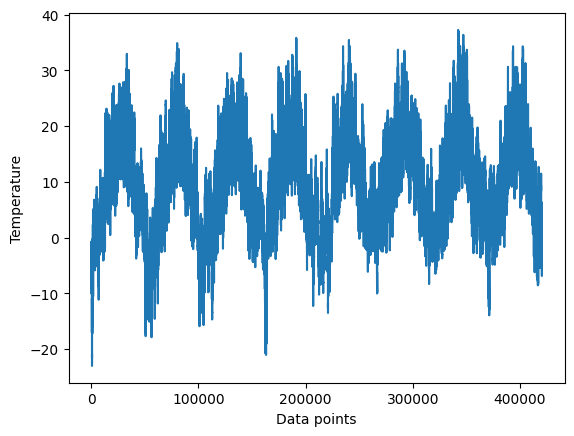

In [ ]:
from matplotlib import pyplot as plt
plt.plot(range(len(temp1)), temp1)
plt.xlabel('Data points')
plt.ylabel('Temperature')

The temperature chart is drawn for the first ten days. If you gather 144 data points each day, then over ten days you’ll collect 1,440 data points.

Text(0, 0.5, 'Temperature')

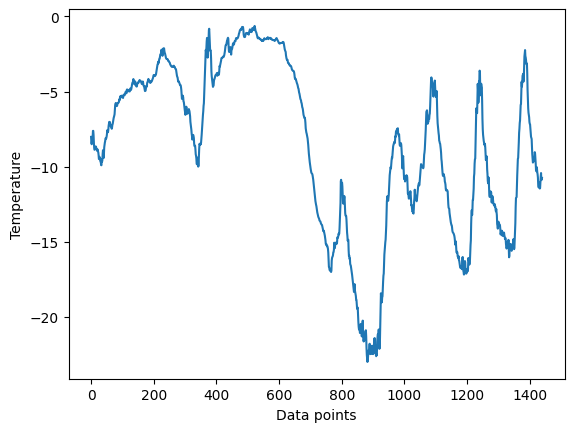

In [ ]:
plt.plot(range(1440), temp1[:1440])
plt.xlabel('Data points')
plt.ylabel('Temperature')

We need to decide how many samples go into each set: 50% for training and 25% for validation.

In [ ]:
num_of_train = int(0.5 * len(rawdata1))
num_of_validation= int(0.25 * len(rawdata1))
num_of_test= len(rawdata1) - num_of_train - num_of_validation
print("Number of train samples:", num_of_train)
print("Number of validation samples:", num_of_validation)
print("Number of test samples:", num_of_test)

Number of train samples: 210225
Number of validation samples: 105112
Number of test samples: 105114


Preparing the data

Data normalisation: Vectorisation is not required because the data is already numerically represented. All variables should be standardised, however, because the data scales are different—temperature ranges from -20 to +30, and pressure is measured in millibars.

In [ ]:
mean1 = rawdata1[:num_of_train].mean(axis=0)
rawdata1 -= mean1
std = rawdata1[:num_of_train].std(axis=0)
rawdata1 /= std

In [ ]:
import numpy as np
from tensorflow import keras
int_sequence1 = np.arange(10)
dummy_dataset1 = keras.utils.timeseries_dataset_from_array(
    data=int_sequence1[:-3],
    targets=int_sequence1[3:],
    sequence_length=3,
    batch_size=2,
)

for inputs, targets in dummy_dataset1:
    for i in range(inputs.shape[0]):
        print([int(x) for x in inputs[i]], int(targets[i]))

[0, 1, 2] 3
[1, 2, 3] 4
[2, 3, 4] 5
[3, 4, 5] 6
[4, 5, 6] 7


The development of training, validation, and testing datasets is crucial because to the substantial amount of duplication in the dataset's sample. It would be inefficient to explicitly allocate RAM for every sample. Rather, real-time sample generation will be used.

In [ ]:
sample_rate = 6
sequencelength = 120
delay = sample_rate * (sequencelength + 24 - 1)
batch_size = 256

training_data = keras.utils.timeseries_dataset_from_array(
    rawdata1[:-delay],
    targets=temp1[delay:],
    sampling_rate=sample_rate,
    sequence_length=sequencelength,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_of_train)

validation_data = keras.utils.timeseries_dataset_from_array(
    rawdata1[:-delay],
    targets=temp1[delay:],
    sampling_rate=sample_rate,
    sequence_length=sequencelength,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_of_train,
    end_index=num_of_train + num_of_validation)

testing_data = keras.utils.timeseries_dataset_from_array(
    rawdata1[:-delay],
    targets=temp1[delay:],
    sampling_rate=sample_rate,
    sequence_length=sequencelength,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_of_train + num_of_validation)

Generating the output of one of this datasets

In [ ]:
for samples, targets in training_data:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

samples shape: (256, 120, 14)
targets shape: (256,)


A common-sense, non-machine-learning baseline

Finding the baseline of common sense MAE: The "evaluate_naive_method" function lays the groundwork for assessing the effectiveness of a straightforward forecasting technique that uses the last value in the input sequence to predict the value that will follow a given value.

In [ ]:
def evaluate_naive_method(dataset):
    total_absolute_error = 0.
    samples_saw = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean1[1]
        total_absolute_error += np.sum(np.abs(preds - targets))
        samples_saw += samples.shape[0]
    return total_absolute_error / samples_saw

print(f"Validation MAE: {evaluate_naive_method(validation_data):.2f}")
print(f"Test MAE: {evaluate_naive_method(testing_data):.2f}")

Validation MAE: 2.44
Test MAE: 2.62


Predicting that the temperature will be the same 24 hours from now is a Common sense basilne approach. The validation mean absolute error (MAE) is 2.44 degrees Celsius whereas the test mean is 2.62 degrees Celsius utilizing this simple baseline. Stated otherwise, there would be an average variance of around 2.5 degrees if the future temperature were constant with the present one.

A basic machine-learning model - Dense Layer

Training and evaluating a densely connected model

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(sequencelength, rawdata1.shape[-1]))
G1 = layers.Flatten()(inputs)
G1 = layers.Dense(16, activation="relu")(G1)
outputs = layers.Dense(1)(G1)
model = keras.Model(inputs, outputs)

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras",
                                    save_best_only=True)]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])


history = model.fit(training_data, epochs=20,
                    validation_data = validation_data, callbacks=callbacks)

Epoch 1/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - loss: 12.5608 - mae: 2.7379 - val_loss: 12.4257 - val_mae: 2.7926
Epoch 2/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 54ms/step - loss: 8.9628 - mae: 2.3539 - val_loss: 10.8201 - val_mae: 2.6077
Epoch 3/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 54ms/step - loss: 8.1873 - mae: 2.2453 - val_loss: 10.0813 - val_mae: 2.5163
Epoch 4/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 54ms/step - loss: 7.7558 - mae: 2.1859 - val_loss: 10.1571 - val_mae: 2.5191
Epoch 5/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 54ms/step - loss: 7.4705 - mae: 2.1437 - val_loss: 11.9179 - val_mae: 2.7277
Epoch 6/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 54ms/step - loss: 7.2458 - mae: 2.1131 - val_loss: 12.1725 - val_mae: 2.7648
Epoch 7/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 81s 53ms/step - loss: 7.0766 - mae: 2.0890 - val_loss: 10.0956 - val_mae: 2.5003
Epoch 8/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - loss: 6.9316 - mae: 2.0670 - val_loss: 10.6438 - val_mae: 2.5776
Epoch 9/20
819/819 ━━━━━━━━━━━━

In [ ]:
model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(testing_data)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - loss: 11.1696 - mae: 2.6415
Test MAE: 2.64


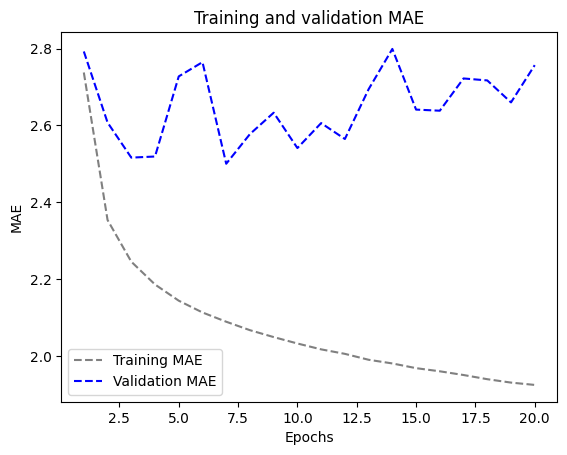

In [ ]:
import matplotlib.pyplot as plt
loss1 = history.history["mae"]
validation_loss = history.history["val_mae"]

epochs = range(1, len(loss1) + 1)
plt.figure()
plt.plot(epochs, loss1, color="grey", linestyle="dashed", label="Training MAE")
plt.plot(epochs,  validation_loss, color="blue",linestyle="dashed", label="Validation MAE")
plt.title("Training and validation MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()

Let's try a 1D convolutional model

In [ ]:
inputs = keras.Input(shape=(sequencelength, rawdata1.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history1D = model.fit(training_data,
                    epochs=10,
                    validation_data=validation_data,
                    callbacks=callbacks)

model_to_dot = keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model.evaluate(testing_data)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 58ms/step - loss: 25.1673 - mae: 3.9113 - val_loss: 17.0506 - val_mae: 3.3002
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 76s 54ms/step - loss: 16.8098 - mae: 3.2496 - val_loss: 18.3904 - val_mae: 3.3643
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - loss: 15.3126 - mae: 3.1072 - val_loss: 17.2500 - val_mae: 3.3565
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - loss: 14.4246 - mae: 3.0163 - val_loss: 15.4499 - val_mae: 3.1303
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - loss: 13.7252 - mae: 2.9407 - val_loss: 16.5976 - val_mae: 3.1897
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - loss: 13.1551 - mae: 2.8785 - val_loss: 15.0437 - val_mae: 3.0904
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - loss: 12.6070 - mae: 2.8163 - val_loss: 17.4658 - val_mae: 3.3219
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - loss: 12.1894 - mae: 2.7670 - val_loss: 18.3761 - val_mae: 3.3084
Epoch 9/10
819/819 ━━━━━

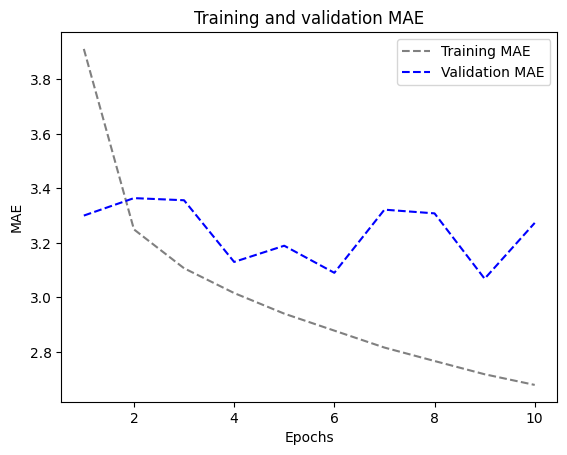

In [ ]:
import matplotlib.pyplot as plt
loss1D = history1D.history["mae"]
validation_loss1D = history1D.history["val_mae"]

epochs = range(1, len(loss1D) + 1)
plt.figure()
plt.plot(epochs, loss1D, color="grey", linestyle="dashed", label="Training MAE")
plt.plot(epochs,  validation_loss1D, color="blue",linestyle="dashed", label="Validation MAE")
plt.title("Training and validation MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()

Dense models and common sense work better than convolutional data. That could be due to the fact that weather records don’t follow the rule of translation invariance. The way the information is presented matters a lot. Data from the recent past helps predict tomorrow’s temperature far better than information gathered days ahead. Unfortunately, a 1D convolutional neural network can’t capture this important sequence of time order well enough.

A Simple RNN

1. An RNN layer that can process sequences of any length

In [ ]:
the_features = 14
input_RNN = keras.Input(shape=(None, the_features))
x = layers.SimpleRNN(16)(input_RNN)
output_RNN = layers.Dense(1)(x)

models_RNN = keras.Model(input_RNN, output_RNN)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_SimRNN.keras",
                                    save_best_only=True)
]
models_RNN.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_RNN = models_RNN.fit(training_data,
                    epochs=5,
                    validation_data=validation_data,
                    callbacks=callbacks)

models_RNN = keras.models.load_model("jena_SimRNN.keras")
print(f"Test MAE: {models_RNN.evaluate(testing_data)[1]:.2f}")

Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 55s 65ms/step - loss: 44.7540 - mae: 4.9086 - val_loss: 12.8832 - val_mae: 2.6810
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - loss: 11.2857 - mae: 2.6066 - val_loss: 9.5322 - val_mae: 2.3944
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - loss: 10.4501 - mae: 2.5209 - val_loss: 9.2826 - val_mae: 2.3723
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 64ms/step - loss: 10.2808 - mae: 2.5004 - val_loss: 9.2544 - val_mae: 2.3658
Epoch 5/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - loss: 10.1804 - mae: 2.4878 - val_loss: 9.2622 - val_mae: 2.3647
405/405 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - loss: 10.3490 - mae: 2.4871
Test MAE: 2.49


2. Simple RNN - Stacking RNN layers

In [ ]:
the_features2 = 14
steps = 120
inpu2 = keras.Input(shape=(steps, the_features2))
a = layers.SimpleRNN(16, return_sequences=True)(inpu2)
a = layers.SimpleRNN(16, return_sequences=True)(a)
outpu2 = layers.SimpleRNN(16)(a)
outpu2 = layers.Dense(1)(outpu2) # Added Dense layer to match target shape
models2 = keras.Model(inpu2, outpu2)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_SRNN2.keras",
                                    save_best_only=True)
]
models2.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history2 = models2.fit(training_data,
                    epochs=5,
                    validation_data=validation_data,
                    callbacks=callbacks)

models2 = keras.models.load_model("jena_SRNN2.keras")
print(f"Test MAE: {models2.evaluate(testing_data)[1]:.2f}")

Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 64s 73ms/step - loss: 36.7200 - mae: 4.3782 - val_loss: 12.2189 - val_mae: 2.6301
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 57s 70ms/step - loss: 11.0442 - mae: 2.5775 - val_loss: 9.4711 - val_mae: 2.3780
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 60s 73ms/step - loss: 10.2042 - mae: 2.4905 - val_loss: 9.9429 - val_mae: 2.4026
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 59s 71ms/step - loss: 9.9523 - mae: 2.4615 - val_loss: 10.0017 - val_mae: 2.4174
Epoch 5/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 57s 69ms/step - loss: 9.7477 - mae: 2.4343 - val_loss: 9.8328 - val_mae: 2.3948
405/405 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - loss: 10.8427 - mae: 2.5432
Test MAE: 2.54


A Simple GRU (Gated Recurrent Unit)

In [ ]:
inputs_GRU = keras.Input(shape=(sequencelength, rawdata1.shape[-1]))
b = layers.GRU(16)(inputs_GRU)
outputs_GRU = layers.Dense(1)(b)
models_GRU = keras.Model(inputs_GRU, outputs_GRU)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_gru.keras",
                                    save_best_only=True)
]
models_GRU.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_GRU = models_GRU.fit(training_data,
                    epochs=5,
                    validation_data=validation_data,
                    callbacks=callbacks)

models_GRU = keras.models.load_model("jena_gru.keras")
print(f"Test MAE: {models_GRU.evaluate(testing_data)[1]:.2f}")

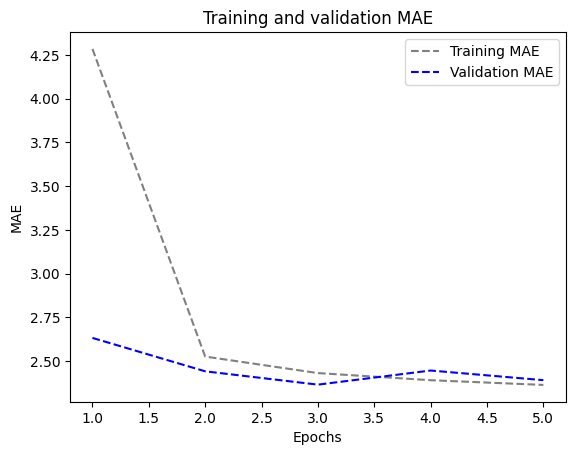

In [ ]:
import matplotlib.pyplot as plt
loss_GRU = history_GRU.history["mae"]
validation_loss_GRU = history_GRU.history["val_mae"]

epochs = range(1, len(loss_GRU) + 1)
plt.figure()
plt.plot(epochs, loss_GRU, color="grey", linestyle="dashed", label="Training MAE")
plt.plot(epochs,  validation_loss_GRU, color="blue",linestyle="dashed", label="Validation MAE")
plt.title("Training and validation MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()

LSTM(Long Short-Term Memory )

1. LSTM-Simple

In [ ]:
inputs_LSTMS = keras.Input(shape=(sequencelength, rawdata1.shape[-1]))
c = layers.LSTM(16)(inputs_LSTMS)
output_LSTMS = layers.Dense(1)(c)
model_LSTMS = keras.Model(inputs_LSTMS, output_LSTMS)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras",
                                    save_best_only=True)
]
model_LSTMS.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_LSTMS = model_LSTMS.fit(training_data,
                    epochs=5,
                    validation_data=validation_data,
                    callbacks=callbacks)

Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 61ms/step - loss: 44.1513 - mae: 4.8478 - val_loss: 12.7203 - val_mae: 2.6934
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - loss: 11.0824 - mae: 2.5842 - val_loss: 9.6553 - val_mae: 2.4008
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 61ms/step - loss: 9.8539 - mae: 2.4441 - val_loss: 9.6350 - val_mae: 2.3996
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - loss: 9.4335 - mae: 2.3877 - val_loss: 9.6399 - val_mae: 2.3983
Epoch 5/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 82s 62ms/step - loss: 9.2028 - mae: 2.3550 - val_loss: 9.4228 - val_mae: 2.3761


In [ ]:
model_LSTMS = keras.models.load_model("jena_lstm.keras")
print(f"Test MAE: {model_LSTMS.evaluate(testing_data)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - loss: 10.6940 - mae: 2.5450
Test MAE: 2.54


In [ ]:
import matplotlib.pyplot as plt
loss_LSTMS = history_LSTMS.history["mae"]
validation_loss_LSTMS = history_LSTMS.history["val_mae"]

epochs = range(1, len(loss_LSTMS) + 1)
plt.figure()
plt.plot(epochs, loss_LSTMS, color="grey", linestyle="dashed", label="Training MAE")
plt.plot(epochs,  validation_loss_LSTMS, color="blue",linestyle="dashed", label="Validation MAE")
plt.title("Training and validation MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()

2. LSTM - dropout Regularization

In [ ]:
input_LSTMR = keras.Input(shape=(sequencelength, rawdata1.shape[-1]))
d = layers.LSTM(16, recurrent_dropout=0.25)(input_LSTMR )
d = layers.Dropout(0.5)(d)
output_LSTMR = layers.Dense(1)(d)
model_LSTMR = keras.Model(input_LSTMR , output_LSTMR )

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm_dropout.keras",
                                    save_best_only=True)
]
model_LSTMR.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_LSTMR = model_LSTMR.fit(training_data,
                    epochs=5,
                    validation_data=validation_data,
                    callbacks=callbacks)

Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 343s 413ms/step - loss: 52.1336 - mae: 5.4013 - val_loss: 13.8652 - val_mae: 2.7976
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 341s 416ms/step - loss: 20.6375 - mae: 3.4841 - val_loss: 9.9681 - val_mae: 2.4575
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 338s 412ms/step - loss: 18.7340 - mae: 3.3327 - val_loss: 9.5034 - val_mae: 2.4011
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 381s 411ms/step - loss: 17.6528 - mae: 3.2403 - val_loss: 9.3737 - val_mae: 2.3836
Epoch 5/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 337s 410ms/step - loss: 17.0035 - mae: 3.1788 - val_loss: 9.1662 - val_mae: 2.3499


In [ ]:
model_LSTMR = keras.models.load_model("jena_lstm_dropout.keras")
print(f"Test MAE: {model_LSTMR.evaluate(testing_data)[1]:.2f}")

In [ ]:
import matplotlib.pyplot as plt
loss_LSTMR = history_LSTMR .history["mae"]
validation_loss_LSTMR = history_LSTMR .history["val_mae"]

epochs = range(1, len(loss_LSTMR) + 1)
plt.figure()
plt.plot(epochs, loss_LSTMR, color="grey", linestyle="dashed", label="Training MAE")
plt.plot(epochs,  validation_loss_LSTMR, color="blue",linestyle="dashed", label="Validation MAE")
plt.title("Training and validation MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()

3. LSTM - Stacked setup with 16 units

In [ ]:
input_16 = keras.Input(shape=(sequencelength, rawdata1.shape[-1]))
e = layers.LSTM(16, return_sequences=True)(input_16)
e = layers.LSTM(16)(e)
output_16 = layers.Dense(1)(e)
model_16 = keras.Model(input_16, output_16)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_LSTM_stacked1.keras",
                                    save_best_only=True)
]
model_16.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_16 = model_16.fit(training_data,
                    epochs=5,
                    validation_data=validation_data,
                    callbacks=callbacks)

Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 55s 65ms/step - loss: 41.1299 - mae: 4.6973 - val_loss: 13.2591 - val_mae: 2.7617
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 65ms/step - loss: 10.4328 - mae: 2.5032 - val_loss: 11.1084 - val_mae: 2.5715
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 64ms/step - loss: 8.9729 - mae: 2.3286 - val_loss: 10.4045 - val_mae: 2.4958
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 65ms/step - loss: 8.2819 - mae: 2.2430 - val_loss: 10.7727 - val_mae: 2.5721
Epoch 5/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 65ms/step - loss: 7.7349 - mae: 2.1676 - val_loss: 10.8387 - val_mae: 2.5814


In [ ]:
model_16 = keras.models.load_model("jena_LSTM_stacked1.keras")
print(f"Test MAE: {model_16.evaluate(testing_data)[1]:.2f}")

In [ ]:
import matplotlib.pyplot as plt
loss_16 = history_16.history["mae"]
validation_loss_16 = history_16.history["val_mae"]

epochs = range(1, len(loss_16) + 1)
plt.figure()
plt.plot(epochs, loss_16, color="grey", linestyle="dashed", label="Training MAE")
plt.plot(epochs,  validation_loss_16, color="blue",linestyle="dashed", label="Validation MAE")
plt.title("Training and validation MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()

4. LSTM - Stacked setup with 32 units

In [ ]:
input_32 = keras.Input(shape=(sequencelength, rawdata1.shape[-1]))
f = layers.LSTM(32, return_sequences=True)(input_32)
f = layers.LSTM(32)(f)
output_32 = layers.Dense(1)(f)
model_32 = keras.Model(input_32, output_32)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_LSTM_stacked2.keras",
                                    save_best_only=True)
]
model_32.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_32 = model_32.fit(training_data,
                    epochs=10,
                    validation_data=validation_data,
                    callbacks=callbacks)

In [13]:
model_32 = keras.models.load_model("jena_LSTM_stacked2.keras")
print(f"Test MAE: {model_32.evaluate(testing_data)[1]:.2f}")

ValueError: File not found: filepath=jena_LSTM_stacked2.keras. Please ensure the file is an accessible `.keras` zip file.

In [12]:
import matplotlib.pyplot as plt
loss_32 = history_32.history["mae"]
validation_loss_32 = history_32.history["val_mae"]

epochs = range(1, len(loss_32) + 1)
plt.figure()
plt.plot(epochs, loss_32, color="grey", linestyle="dashed", label="Training MAE")
plt.plot(epochs,  validation_loss_32, color="blue",linestyle="dashed", label="Validation MAE")
plt.title("Training and validation MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()

NameError: name 'history_32' is not defined

5. LSTM - Stacked setup with 8 units

In [38]:
input_8u = keras.Input(shape=(sequencelength, rawdata1.shape[-1]))
h = layers.LSTM(8, return_sequences=True)(input_8u)
h = layers.LSTM(8)(h)
output_8u = layers.Dense(1)(h)
model_8u = keras.Model(input_8u, output_8u)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_LSTM_stacked3.keras",
                                    save_best_only=True)
]
model_8u.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_8u = model_8u.fit(training_data,
                    epochs=10,
                    validation_data=validation_data,
                    callbacks=callbacks)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 55s 66ms/step - loss: 75.3068 - mae: 6.6831 - val_loss: 38.6849 - val_mae: 4.6681
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 66ms/step - loss: 23.5006 - mae: 3.6011 - val_loss: 13.9231 - val_mae: 2.8088
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 64ms/step - loss: 12.0023 - mae: 2.6823 - val_loss: 10.3425 - val_mae: 2.4967
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 64ms/step - loss: 10.3676 - mae: 2.5143 - val_loss: 9.4811 - val_mae: 2.3985
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 65ms/step - loss: 9.8082 - mae: 2.4462 - val_loss: 9.4248 - val_mae: 2.3875
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 83s 65ms/step - loss: 9.5228 - mae: 2.4126 - val_loss: 9.5569 - val_mae: 2.4062
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 66ms/step - loss: 9.3170 - mae: 2.3882 - val_loss: 9.4094 - val_mae: 2.3867
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 66ms/step - loss: 9.1348 - mae: 2.3650 - val_loss: 9.5635 - val_mae: 2.4126
Epoch 9/10
819/819 ━━━━━━━━━━━━━━

In [39]:
model_8u = keras.models.load_model("jena_LSTM_stacked3.keras")
print(f"Test MAE: {model_8u.evaluate(testing_data)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - loss: 10.6848 - mae: 2.5543
Test MAE: 2.55


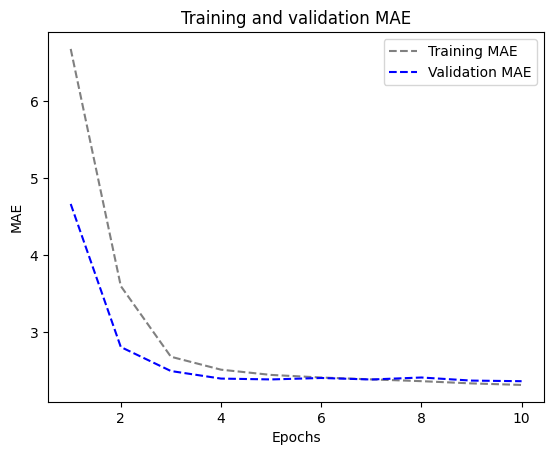

In [40]:
import matplotlib.pyplot as plt
loss_8u = history_8u.history["mae"]
validation_loss_8u = history_8u.history["val_mae"]

epochs = range(1, len(loss_8u) + 1)
plt.figure()
plt.plot(epochs, loss_8u, color="grey", linestyle="dashed", label="Training MAE")
plt.plot(epochs,  validation_loss_8u, color="blue",linestyle="dashed", label="Validation MAE")
plt.title("Training and validation MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()

6. LSTM - dropout-regularized, stacked model

In [7]:
import os
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import subprocess

# --- Start of added code for data loading and preprocessing ---
file_path = os.path.join("/content", "jena_climate_2009_2016.csv")
zip_path = os.path.join("/content", "jena_climate_2009_2016.csv.zip")

# Check if the CSV file exists, if not, download and unzip
if not os.path.exists(file_path):
    print("Jena climate data not found. Attempting to download and unzip...")
    try:
        # Download the zip file if it doesn't exist
        if not os.path.exists(zip_path):
            print("Downloading jena_climate_2009_2016.csv.zip...")
            subprocess.run(["wget", "https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip", "-P", "/content/"], check=True)
            print("Download complete.")

        # Unzip the file
        print("Unzipping jena_climate_2009_2016.csv.zip...")
        subprocess.run(["unzip", "-o", zip_path, "-d", "/content/"], check=True) # -o for overwrite, -d for directory
        print("Unzip complete. Data file should now be available.")
    except subprocess.CalledProcessError as e:
        print(f"Error during data download or unzip: {e}")
        # Re-raise the exception or handle appropriately if you want the cell to stop here
        raise

fname = file_path # Use the verified file path

with open(fname) as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]

temp1 = np.zeros((len(lines),))
rawdata1 = np.zeros((len(lines), len(header) - 1))
for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temp1[i] = values[1]
    rawdata1[i, :] = values[:]

num_of_train = int(0.5 * len(rawdata1))
num_of_validation = int(0.25 * len(rawdata1))
num_of_test = len(rawdata1) - num_of_train - num_of_validation

mean1 = rawdata1[:num_of_train].mean(axis=0)
rawdata1 -= mean1
std = rawdata1[:num_of_train].std(axis=0)
rawdata1 /= std

sample_rate = 6
sequencelength = 120
delay = sample_rate * (sequencelength + 24 - 1)
batch_size = 256

training_data = keras.utils.timeseries_dataset_from_array(
    rawdata1[:-delay],
    targets=temp1[delay:],
    sampling_rate=sample_rate,
    sequence_length=sequencelength,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_of_train)

validation_data = keras.utils.timeseries_dataset_from_array(
    rawdata1[:-delay],
    targets=temp1[delay:],
    sampling_rate=sample_rate,
    sequence_length=sequencelength,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_of_train,
    end_index=num_of_train + num_of_validation)

testing_data = keras.utils.timeseries_dataset_from_array(
    rawdata1[:-delay],
    targets=temp1[delay:],
    sampling_rate=sample_rate,
    sequence_length=sequencelength,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_of_train + num_of_validation)
# --- End of added code for data loading and preprocessing ---

inputs = keras.Input(shape=(sequencelength, rawdata1.shape[-1]))
i = layers.LSTM(8, recurrent_dropout=0.5, return_sequences=True)(inputs)
i = layers.LSTM(8, recurrent_dropout=0.5)(i)
i = layers.Dropout(0.5)(i)
outputs = layers.Dense(1)(i)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_stacked_LSTM_dropout.keras",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(training_data,
                    epochs=10,
                    validation_data=validation_data,
                    callbacks=callbacks)

Jena climate data not found. Attempting to download and unzip...
Download complete.
Unzipping jena_climate_2009_2016.csv.zip...
Unzip complete. Data file should now be available.
Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 208s 246ms/step - loss: 75.3979 - mae: 6.7156 - val_loss: 35.3113 - val_mae: 4.4210
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 198s 241ms/step - loss: 31.8495 - mae: 4.2205 - val_loss: 13.9308 - val_mae: 2.7754
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 203s 242ms/step - loss: 24.4104 - mae: 3.7354 - val_loss: 11.7020 - val_mae: 2.6250
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 211s 258ms/step - loss: 22.2338 - mae: 3.5815 - val_loss: 10.5986 - val_mae: 2.5125
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 200s 244ms/step - loss: 21.0496 - mae: 3.4926 - val_loss: 10.4180 - val_mae: 2.5014
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 200s 244ms/step - loss: 20.1553 - mae: 3.4148 - val_loss: 10.1445 - val_mae: 2.4672
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 205s 250ms/step - loss: 19.3815 - mae

In [8]:
model_r = keras.models.load_model("jena_stacked_LSTM_dropout.keras")
print(f"Test MAE: {model_r.evaluate(testing_data)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 36s 85ms/step - loss: 10.7499 - mae: 2.5518
Test MAE: 2.55


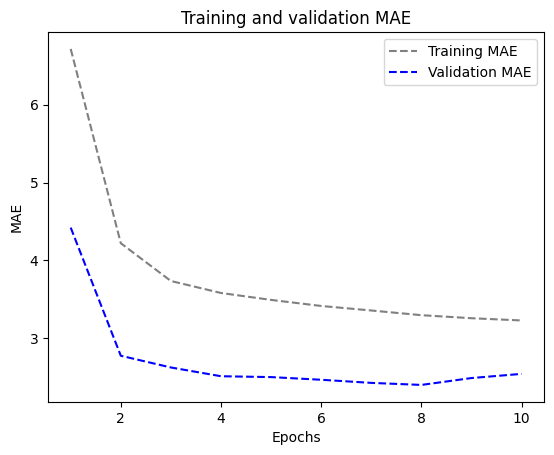

In [9]:
import matplotlib.pyplot as plt
loss_r = history.history["mae"]
validation_loss_r = history.history["val_mae"]

epochs = range(1, len(loss_r) + 1)
plt.figure()
plt.plot(epochs, loss_r, color="grey", linestyle="dashed", label="Training MAE")
plt.plot(epochs,  validation_loss_r, color="blue",linestyle="dashed", label="Validation MAE")
plt.title("Training and validation MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()

Bidirectional LSTM

In [10]:
inputs = keras.Input(shape=(sequencelength, rawdata1.shape[-1]))
x = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_bidirec_LSTM.keras",
                                    save_best_only=True)
]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history.bi = model.fit(training_data,
                    epochs=5,
                    validation_data=validation_data,
                     callbacks=callbacks)

Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 146s 174ms/step - loss: 30.2550 - mae: 3.9404 - val_loss: 10.8236 - val_mae: 2.5436
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 143s 174ms/step - loss: 9.7099 - mae: 2.4412 - val_loss: 9.7111 - val_mae: 2.3951
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 203s 176ms/step - loss: 8.7382 - mae: 2.3120 - val_loss: 9.9526 - val_mae: 2.4221
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 143s 175ms/step - loss: 8.2676 - mae: 2.2418 - val_loss: 9.5710 - val_mae: 2.3818
Epoch 5/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 142s 173ms/step - loss: 7.8998 - mae: 2.1886 - val_loss: 10.1079 - val_mae: 2.4525


In [14]:
model_bi = keras.models.load_model("jena_bidirec_LSTM.keras")
print(f"Test MAE: {model_bi.evaluate(testing_data)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 34s 81ms/step - loss: 10.4010 - mae: 2.5253
Test MAE: 2.53


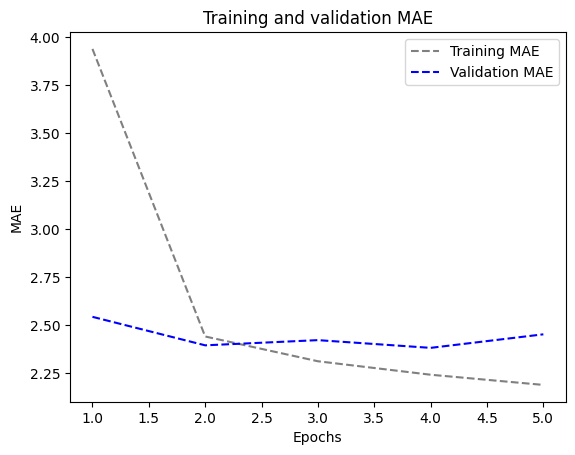

In [15]:
import matplotlib.pyplot as plt
loss_bi = history.bi.history["mae"]
validation_loss_bi = history.bi.history["val_mae"]

epochs = range(1, len(loss_bi) + 1)
plt.figure()
plt.plot(epochs, loss_bi, color="grey", linestyle="dashed", label="Training MAE")
plt.plot(epochs,  validation_loss_bi, color="blue",linestyle="dashed", label="Validation MAE")
plt.title("Training and validation MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()

1D Convnets and LSTM togther

In [16]:
input_final = keras.Input(shape=(sequencelength, rawdata1.shape[-1]))
l = layers.Conv1D(64, 3, activation='relu')(input_final)
l = layers.MaxPooling1D(3)(l)
l = layers.Conv1D(128, 3, activation='relu')(l)
l = layers.GlobalMaxPooling1D()(l)
l = layers.Reshape((-1, 128))(l)  # Reshape the data to be 3D
l = layers.LSTM(16)(l)
output_final = layers.Dense(1)(l)
model_final = keras.Model(input_final, output_final)

model_final.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_Conv_LSTM.keras", save_best_only=True)
]

history_final = model_final.fit(training_data, epochs=5, validation_data=validation_data, callbacks=callbacks)

Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 120s 144ms/step - loss: 48.7717 - mae: 5.2102 - val_loss: 26.1551 - val_mae: 3.9543
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 115s 140ms/step - loss: 17.5366 - mae: 3.2298 - val_loss: 24.2672 - val_mae: 3.8516
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 116s 141ms/step - loss: 14.4619 - mae: 2.9490 - val_loss: 21.3469 - val_mae: 3.6678
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 117s 142ms/step - loss: 12.8822 - mae: 2.7762 - val_loss: 23.8252 - val_mae: 3.8112
Epoch 5/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 116s 141ms/step - loss: 11.7666 - mae: 2.6436 - val_loss: 25.3832 - val_mae: 4.0149
